# SNP Embedding → 基因表达 建模

基于个人 SNP embedding 预测基因表达水平（log2 TPM）。

## 概述

**目标**：用个体的 SNP hidden states（来自 Genos 预训练模型）预测每个基因的 log2(TPM) 表达水平。

**流程**：
1. 从 embedding 目录的 `meta.json` 自动发现基因 → 与表达矩阵取交集（个体 + 基因双维度） → 按 rank 顺序取前 `N_GENES` 个
2. 输入侧：每个 (基因, 个体) 的 SNP embedding 减去训练集均值 center，得到 SNP delta
3. 目标侧：原始 log2(TPM) 做 per-gene Z-score 标准化后训练
4. Attention Pooling 模型（`SpecificSNPRegressor`）聚合 SNP 信息 → 预测标准化后的表达值 → 逆变换还原
5. 评估指标：Pearson / Spearman / R²（跨个体）

> ⚠️ 基因若无训练集表达值，会在数据构建阶段自动剔除（`build_multi_gene_data_from_matrix`）。

---

## 输入文件

| 输入 | 路径（在 Cell 1 中配置） | 说明 |
|------|--------------------------|------|
| **SNP Embedding 目录** | `EMBEDDING_ROOT` | 每个基因一个子目录，内含 `meta.json` + 各样本的 `.vcf.pt` |
| **表达矩阵** | `EXPRESSION_MATRIX` | `.tsv.gz`，行为基因 symbol，列为 CIMA 个体 ID，值为 log2(TPM) |
| **个体表** | `SAMPLE_FILE` | 两列 TSV：accession、sample（H 编号） |

## 输出文件

| 文件 | 内容 |
|------|------|
| `model_{variant}_{n_genes}.pt` | 完整 checkpoint（模型权重 + 基因元信息 + 预处理参数） |
| `history.csv` | 每 epoch 的 train/val loss 和 macro pearson/r² |
| `predictions.csv` | 所有样本的预测值（target / prediction，log2 TPM） |
| `metrics_overall.csv` | 全局指标（RMSE, MAE, Pearson, R²） |
| `metrics_by_gene.csv` | 每个基因的独立指标 |
| `metrics_macro.csv` | 跨基因 macro 聚合指标 |

1. 导入package和读入数据

In [1]:
from __future__ import annotations
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# ============================================================
# 路径配置（按需修改）
# ============================================================
SCRIPT_DIR = Path("/mnt/rice/default/Workspace/yangdong/ai4research/md0722/gene/script2")

# SNP Embedding 根目录 —— 每个基因一个子目录，内含 meta.json + 各样本 .vcf.pt
EMBEDDING_ROOT = Path("/mnt/rice/default/Workspace/xuxiaolong/human/SNPembedding_top1000_common_TSS_1Mb")

# 表达矩阵 —— 行为基因 symbol，列为 CIMA 个体 ID，值为 log2(TPM)
EXPRESSION_MATRIX = "/mnt/genos100-new/peixunban/yecheng/data/CIMA/Monocyte_matrix_log2_TPM_annot.tsv.gz"

# 个体映射表（accession ↔ sample）
SAMPLE_FILE = SCRIPT_DIR / "configs" / "101samples.name.txt"

# 输出目录
OUTPUT_DIR = SCRIPT_DIR / "outputs2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 导入项目模块
# ============================================================
sys.path.insert(0, str(SCRIPT_DIR))

from src.models import SpecificSNPRegressor, SpecificSNPTransformerCNN
from src.data import read_sample_table, extract_gene_symbol, load_expression_matrix
from src.training import run_experiment

print(f"输出目录: {OUTPUT_DIR}")
print(f"Embedding 根目录: {EMBEDDING_ROOT}")


输出目录: /mnt/rice/default/Workspace/yangdong/ai4research/md0722/gene/script2/outputs2
Embedding 根目录: /mnt/rice/default/Workspace/xuxiaolong/human/SNPembedding_top1000_common_TSS_1Mb


2. subset对齐，从个体与基因两个维度

In [2]:
# ── 读取个体表 ──
sample_table = read_sample_table(SAMPLE_FILE)
display(sample_table.head())
all_individuals = sample_table["sample"].tolist()  # ["H005", "H009", ...]
print(f"个体表中共 {len(all_individuals)} 个个体")

# ── 个体维度对齐：检查哪些个体在表达矩阵中有数据 ──
# 矩阵列名原始格式: "CIMA_H005" (下划线)
cima_ids_all = ["CIMA_" + s for s in all_individuals]
expr_cols = pd.read_csv(EXPRESSION_MATRIX, sep="\t", nrows=0).columns.tolist()
available_cima = [c for c in cima_ids_all if c in expr_cols]
missing_samples = set(all_individuals) - set(c.replace("CIMA_", "") for c in available_cima)
print(f"表达矩阵中存在 {len(available_cima)}/{len(all_individuals)} 个个体")
if missing_samples:
    print(f"⚠ 不在表达矩阵中的个体: {sorted(missing_samples)}")

# 统一格式: "CIMA_H005" → "CIMA-H005"
all_individuals = sorted(c.replace("CIMA_", "CIMA-") for c in available_cima)
sample_to_accession = dict(zip(sample_table["sample"], sample_table["accession"]))

,accession,sample
0,CNS1171714,H005
1,CNS1171718,H009
2,CNS1171719,H010
3,CNS1171722,H013
4,CNS1171733,H024


个体表中共 101 个个体
表达矩阵中存在 101/101 个个体


3. 设置随机种子 
选择使用的个体数，设置train:val:test=8:1:1，打印使用的个体信息
选择使用的基因数，设置100，则取rank前100

In [3]:
# ============================================================
# 随机种子
# ============================================================
RANDOM_STATE = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# ============================================================
# 个体划分：随机 8:1:1 (train:val:test)
# ============================================================
n = len(all_individuals)
inds = all_individuals.copy()
random.shuffle(inds)

n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_individuals = sorted(inds[:n_train])
val_individuals = sorted(inds[n_train:n_train + n_val])
test_individuals = sorted(inds[n_train + n_val:])

val_set = set(val_individuals)
test_set = set(test_individuals)

# 汇总
print(f"个体总数: {len(all_individuals)}")
print(f"  train (80%): {len(train_individuals)}")
print(f"  val   (10%): {len(val_individuals)}")
print(f"  test  (10%): {len(test_individuals)}")
print(f"\nTrain: {train_individuals}")
print(f"Val:   {val_individuals}")
print(f"Test:  {test_individuals}")
print(f"Device: {DEVICE}")

个体总数: 101
  train (80%): 80
  val   (10%): 10
  test  (10%): 11

Train: ['CIMA-H009', 'CIMA-H010', 'CIMA-H013', 'CIMA-H026', 'CIMA-H030', 'CIMA-H031', 'CIMA-H032', 'CIMA-H033', 'CIMA-H045', 'CIMA-H050', 'CIMA-H052', 'CIMA-H055', 'CIMA-H057', 'CIMA-H063', 'CIMA-H068', 'CIMA-H069', 'CIMA-H078', 'CIMA-H083', 'CIMA-H086', 'CIMA-H092', 'CIMA-H093', 'CIMA-H095', 'CIMA-H097', 'CIMA-H101', 'CIMA-H103', 'CIMA-H107', 'CIMA-H112', 'CIMA-H117', 'CIMA-H118', 'CIMA-H120', 'CIMA-H123', 'CIMA-H125', 'CIMA-H126', 'CIMA-H136', 'CIMA-H137', 'CIMA-H138', 'CIMA-H140', 'CIMA-H149', 'CIMA-H155', 'CIMA-H156', 'CIMA-H159', 'CIMA-H162', 'CIMA-H170', 'CIMA-H179', 'CIMA-H185', 'CIMA-H188', 'CIMA-H190', 'CIMA-H195', 'CIMA-H197', 'CIMA-H198', 'CIMA-H202', 'CIMA-H204', 'CIMA-H205', 'CIMA-H209', 'CIMA-H211', 'CIMA-H220', 'CIMA-H223', 'CIMA-H225', 'CIMA-H227', 'CIMA-H228', 'CIMA-H232', 'CIMA-H233', 'CIMA-H235', 'CIMA-H240', 'CIMA-H249', 'CIMA-H259', 'CIMA-H261', 'CIMA-H264', 'CIMA-H268', 'CIMA-H276', 'CIMA-H278', 'CIM

## 3. 基因选择

从 embedding 目录的 `meta.json` 自动发现所有基因（无需 BED/GTF），目录名已编码 rank 顺序（`001_RETN`, `002_NT5C3B`, ...），按此顺序取前 `N_GENES` 个。

> 修改 `N_GENES` 即可控制基因数量。

In [4]:
import json
from dataclasses import dataclass


@dataclass
class GeneInfo:
    """轻量基因元信息 —— 仅从 meta.json 提取，无需 GTF。"""
    embedding_name: str   # 目录名，如 "001_RETN"
    name: str             # BED 风格名，如 "RETN||" (兼容旧格式 "RETN|ENST...|win_4")
    chrom: str
    start: int
    end: int
    strand: str = "+"     # 默认正链（meta.json 中无此字段）
    transcript_id: str = ""  # 默认空（meta.json 中无此字段）


def discover_genes_from_embeddings(embedding_root: Path) -> list[GeneInfo]:
    """从 embedding 目录的 meta.json 发现所有基因（无需 GTF/BED）。

    兼容两种 meta.json 格式：
    - 旧版: {"name": "RETN_ENST..._win_4", "chrom": "chr19", ...}
    - 新版: {"gene_id": "RETN", "chrom": "chr19", ...}

    自动跳过 n_embedding_snps==0 的"空"基因（如 TMEM176A/B）。
    """
    genes = []
    for meta_path in sorted(embedding_root.glob("*/meta.json")):
        meta = json.loads(meta_path.read_text())

        # 跳过无 SNP 的基因（skipped_no_snps）
        if meta.get("n_embedding_snps", 0) == 0:
            continue

        emb_name = meta_path.parent.name
        # 兼容新旧格式
        if "gene_id" in meta:
            gene_id = meta["gene_id"]
            # 新版: name 用 gene_id 构造
            bed_name = f"{gene_id}||"
        elif "name" in meta:
            # 旧版: 替换前两个下划线为竖线
            bed_name = meta["name"].replace("_", "|", 2)
        else:
            raise KeyError(f"meta.json in {emb_name} has neither 'gene_id' nor 'name'")
        genes.append(GeneInfo(
            embedding_name=emb_name,
            name=bed_name,
            chrom=meta["chrom"],
            start=int(meta["start"]),
            end=int(meta["end"]),
        ))
    return genes


# ============================================================
# 基因数量（取前 N 个，目录名已编码 rank 顺序）
# ============================================================
N_GENES = 100

all_genes = discover_genes_from_embeddings(EMBEDDING_ROOT)
# 目录按 001_, 002_, ... 排序，天然对应 rank 顺序
genes = all_genes[:N_GENES]

skipped = 0
for meta_path in sorted(EMBEDDING_ROOT.glob("*/meta.json")):
    meta = json.loads(meta_path.read_text())
    if meta.get("n_embedding_snps", 0) == 0:
        skipped += 1
        print(f"  跳过空基因: {meta_path.parent.name} ({meta.get('gene_id', '?')})")
print(f"\nEmbedding 目录下共 {len(all_genes)} 个基因（已跳过 {skipped} 个空基因），使用前 {len(genes)} 个 (rank顺序)")

  跳过空基因: 006_TMEM176B (TMEM176B)
  跳过空基因: 012_TMEM176A (TMEM176A)
  跳过空基因: 037_CLCN1 (CLCN1)
  跳过空基因: 131_EPHB4 (EPHB4)
  跳过空基因: 136_TSPAN33 (TSPAN33)
  跳过空基因: 271_IRF5 (IRF5)
  跳过空基因: 341_CPED1 (CPED1)
  跳过空基因: 363_COPG2 (COPG2)
  跳过空基因: 399_COL26A1 (COL26A1)
  跳过空基因: 400_KLRG2 (KLRG2)
  跳过空基因: 516_RASA4 (RASA4)
  跳过空基因: 546_UPK3BL1 (UPK3BL1)
  跳过空基因: 597_WDR86 (WDR86)
  跳过空基因: 667_POLR2J (POLR2J)
  跳过空基因: 977_LRRC61 (LRRC61)

Embedding 目录下共 985 个基因（已跳过 15 个空基因），使用前 100 个 (rank顺序)


## 4. 训练配置与执行

选择基因集规模、设置超参数，然后启动训练。所有可调参数集中在此 Cell。

In [5]:
# ── 预览表达矩阵 subset ──
gene_symbols = [extract_gene_symbol(g.embedding_name) for g in genes]

expr_subset = load_expression_matrix(EXPRESSION_MATRIX, all_individuals, gene_symbols)
print(f"表达矩阵 subset: {expr_subset.shape[0]} 基因 × {expr_subset.shape[1]} 个体")
print(f"值范围: [{expr_subset.min().min():.2f}, {expr_subset.max().max():.2f}]")

missing = set(gene_symbols) - set(expr_subset.index)
if missing:
    print(f"⚠ 在 embedding 中但不在表达矩阵中的基因: {missing}")
display(expr_subset.head())

  Expression matrix subset: 100 genes × 101 individuals
表达矩阵 subset: 100 基因 × 101 个体
值范围: [-6.64, 11.84]


,CIMA-H056,CIMA-H055,CIMA-H057,CIMA-H052,CIMA-H031,CIMA-H063,CIMA-H064,CIMA-H068,CIMA-H069,CIMA-H078,...,CIMA-H322,CIMA-H318,CIMA-H317,CIMA-H320,CIMA-H324,CIMA-H323,CIMA-H319,CIMA-H010,CIMA-H026,CIMA-H030
gene_id,,,,,,,,,,,,,,,,,,,,,
AATK,0.178065,0.395941,1.724268,1.085906,1.183315,1.116186,1.423110,0.615488,-0.251140,1.708419,...,1.463077,0.676991,2.162066,1.275271,1.235079,0.335250,1.599017,1.128882,0.806846,0.311029
ABO,0.127061,-3.898083,0.794560,-3.288505,-0.187306,-1.804912,0.765350,-0.911961,-1.388521,-1.138476,...,0.062374,-0.269416,-1.706560,-6.643856,-6.643856,-1.472096,-2.690271,-3.078694,-0.410888,-6.643856
ACAD9,1.944729,2.239954,2.060068,2.463353,2.465039,2.413298,2.574376,2.783430,3.841022,1.996499,...,2.212218,2.409850,1.822793,2.333286,2.483361,2.326370,3.442297,2.318924,2.725902,2.193707
ACCS,4.147161,2.861316,2.723862,4.217980,4.368454,2.385549,3.312800,2.154987,3.430223,3.097325,...,3.246068,4.168769,3.894560,3.251903,3.169810,4.212528,4.085598,4.235370,4.109608,4.779421
ACP5,3.234879,4.069789,4.227240,4.286668,5.203804,4.642808,4.017215,3.519319,3.653265,5.222369,...,5.214577,3.545312,3.463294,5.294534,4.282457,4.315414,5.555727,3.459151,5.624762,5.428805


```
表达矩阵 (log2 TPM)                     SNP Embedding
      │                                       │
      ▼                                       ▼
  y = 原始 log2(TPM)               individual hidden state
      │                                       │
      ▼                                       ▼
  per-gene Z-score:                 减去训练集均值 center
  y_scaled = (y - μ) / σ            → SNP delta（输入侧的 delta）
      │                                      
      ▼                                      
  ┌─────────────────────────────────────────┐
  │            SpecificSNPRegressor         │
  │  输入: SNP delta + position + gene_id   │
  │  输出: ŷ_scaled（标准化后的 log2TPM）    │
  └─────────────────────────────────────────┘
      │
      ▼
  Inverse Z-score:
  prediction = ŷ_scaled × σ + μ
  → 还原为绝对的 log2(TPM) 值
  ```

In [6]:
print(f"all: {all_individuals}")
print(f"train: {train_individuals}")
print(f"val: {val_individuals}")
print(f"test: {test_individuals}")
print(expr_subset.shape)

all: ['CIMA-H005', 'CIMA-H009', 'CIMA-H010', 'CIMA-H013', 'CIMA-H024', 'CIMA-H026', 'CIMA-H029', 'CIMA-H030', 'CIMA-H031', 'CIMA-H032', 'CIMA-H033', 'CIMA-H037', 'CIMA-H045', 'CIMA-H048', 'CIMA-H050', 'CIMA-H052', 'CIMA-H055', 'CIMA-H056', 'CIMA-H057', 'CIMA-H063', 'CIMA-H064', 'CIMA-H068', 'CIMA-H069', 'CIMA-H078', 'CIMA-H083', 'CIMA-H086', 'CIMA-H092', 'CIMA-H093', 'CIMA-H095', 'CIMA-H097', 'CIMA-H101', 'CIMA-H102', 'CIMA-H103', 'CIMA-H107', 'CIMA-H109', 'CIMA-H112', 'CIMA-H117', 'CIMA-H118', 'CIMA-H120', 'CIMA-H123', 'CIMA-H125', 'CIMA-H126', 'CIMA-H129', 'CIMA-H135', 'CIMA-H136', 'CIMA-H137', 'CIMA-H138', 'CIMA-H140', 'CIMA-H146', 'CIMA-H149', 'CIMA-H155', 'CIMA-H156', 'CIMA-H157', 'CIMA-H159', 'CIMA-H162', 'CIMA-H170', 'CIMA-H179', 'CIMA-H185', 'CIMA-H188', 'CIMA-H190', 'CIMA-H195', 'CIMA-H197', 'CIMA-H198', 'CIMA-H202', 'CIMA-H204', 'CIMA-H205', 'CIMA-H209', 'CIMA-H211', 'CIMA-H215', 'CIMA-H220', 'CIMA-H223', 'CIMA-H224', 'CIMA-H225', 'CIMA-H227', 'CIMA-H228', 'CIMA-H232', 'CIMA-

In [ ]:
# ============================================================
# 超参数（集中配置，按需修改）
# ============================================================
BATCH_SIZE = 16             # A40 46GB, cached delta 模式下可开到 64+
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.3
PROJECTION_DIM = 64
GENE_EMBEDDING_DIM = 32
PATIENCE = 40
LOSS_TYPE = "huber"         # "huber" | "pairwise" | "mixed"

# ============================================================
# 推断 hidden_dim（从第一个基因的第一个个体的 embedding 中读取）
# ============================================================
from src.data import load_hap1_payload

try:
    sample_states, _, _ = load_hap1_payload(genes[0], all_individuals[0], EMBEDDING_ROOT)
    hidden_dim = sample_states.shape[1]
except Exception:
    hidden_dim = 1024
print(f"hidden_dim = {hidden_dim}  (基因数 = {len(genes)})")

# ============================================================
# 模型配置 & 训练
# ============================================================
model_config = {
    "hidden_dim": hidden_dim,
    "n_genes": len(genes),
    "projection_dim": PROJECTION_DIM,
    "gene_embedding_dim": GENE_EMBEDDING_DIM,
    "dropout": DROPOUT,
}

result = run_experiment(
    genes=genes,
    all_individuals=all_individuals,
    train_individuals=train_individuals,
    val_individuals=val_set,
    test_individuals=test_set,
    embedding_root=EMBEDDING_ROOT,
    expression_matrix_path=expr_subset,
    output_dir=OUTPUT_DIR,
    model_class=SpecificSNPRegressor,
    model_config=model_config,
    gene_set_size=len(genes),
    model_variant="specific_snp_delta_hap1",
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    patience=PATIENCE,
    loss_type=LOSS_TYPE,
    device=DEVICE,
    random_state=RANDOM_STATE,
)


hidden_dim = 1024  (基因数 = 100)
Building data for 100 genes...
  Target source: pre-loaded expression matrix ((100, 101))
  Using pre-loaded expression matrix: 100 genes × 101 individuals
  Processing: 001_RETN  (RETN)
  Processing: 002_NT5C3B  (NT5C3B)
  Processing: 003_ACCS  (ACCS)
  Processing: 004_FAM118A  (FAM118A)
  Processing: 005_ERAP2  (ERAP2)
  Processing: 007_RPS26  (RPS26)
  Processing: 008_CCZ1B  (CCZ1B)
  Processing: 009_TREML4  (TREML4)
  Processing: 010_DDX11  (DDX11)
  Processing: 011_NUDT2  (NUDT2)
  Processing: 013_YBEY  (YBEY)
  Processing: 014_GSTM4  (GSTM4)
  Processing: 015_FOLR3  (FOLR3)
  Processing: 016_SNX7  (SNX7)
  Processing: 017_MARCO  (MARCO)
  Processing: 018_NT5DC4  (NT5DC4)
  Processing: 019_SERINC2  (SERINC2)
  Processing: 020_PEX6  (PEX6)
  Processing: 021_SPSB2  (SPSB2)
  Processing: 022_PWP2  (PWP2)
  Processing: 023_TACSTD2  (TACSTD2)
  Processing: 024_ZNF780A  (ZNF780A)
  Processing: 025_CCDC122  (CCDC122)
  Processing: 026_ABO  (ABO)
  Processin

## 5. 查看结果

训练完成后，`result` 字典包含以下 DataFrame：

| Key | 内容 |
|-----|------|
| `result["overall"]` | 全局指标（RMSE, MAE, Pearson, R²） |
| `result["by_gene"]` | 每个基因的独立指标 |
| `result["macro"]` | 跨基因 macro 聚合 |
| `result["predictions"]` | 所有样本的预测值 |
| `result["history"]` | 每 epoch 的训练曲线 |

In [ ]:
result

{'overall':    gene_set_size            model_variant      model_state  split    n  \
 0             10  specific_snp_delta_hap1  best_validation  train  810   
 1             10  specific_snp_delta_hap1  best_validation    val  100   
 2             10  specific_snp_delta_hap1  best_validation   test  100   
 3             10  specific_snp_delta_hap1    best_training  train  810   
 
        rmse       mae   pearson        r2  target_std  prediction_std  
 0  0.606546  0.333714  0.977133  0.954756    2.851565        2.781945  
 1  1.039421  0.360810  0.945182  0.889104    3.121288        2.779221  
 2  0.575316  0.357674  0.979102  0.955173    2.717298        2.763120  
 3  0.180206  0.092487  0.998020  0.996006    2.851565        2.831086  ,
 'by_gene':     gene_set_size            model_variant  split      model_state  gene_id  \
 0              10  specific_snp_delta_hap1  train  best_validation        0   
 1              10  specific_snp_delta_hap1  train  best_validation        

In [ ]:
# ============================================================
# 宏观指标（best_validation）
# ============================================================
print("=== 宏观指标 (best_validation) ===")
display(result["macro"][result["macro"]["model_state"] == "best_validation"])

# ============================================================
# Per-gene 排序（validation set, top 5 by R²）
# ============================================================
print("\n=== Top 5 基因 (validation R²) ===")
bg = result["by_gene"]
val_bg = bg[(bg["model_state"] == "best_validation") & (bg["split"] == "val")]
display(val_bg.nlargest(5, "r2")[["embedding_name", "n", "pearson", "r2", "target_std"]])


=== Macro Metrics (best_validation) ===


,gene_set_size,model_variant,model_state,split,macro_rmse,macro_mae,macro_pearson,macro_r2,n_genes_total,n_genes_variable,n_pearson_valid,n_r2_valid
0,10,specific_snp_delta_hap1,best_validation,train,0.453673,0.333714,0.342690,0.091060,10,10,10,10
1,10,specific_snp_delta_hap1,best_validation,val,0.582049,0.360810,0.102858,-0.051561,10,10,10,10
2,10,specific_snp_delta_hap1,best_validation,test,0.462841,0.357674,0.045345,-0.213570,10,10,10,10



=== Top 5 genes by validation R² ===


,embedding_name,n,pearson,r2,target_std
12,NAPRT_ENST00000340490.7_win_45,10,0.543993,0.162487,0.425361
10,RPS3A_ENST00000274065.9_win_21,10,0.492385,0.061974,0.197417
16,TRAPPC1_ENST00000540486.5_win_84,10,0.224645,0.009056,0.153759
13,SSNA1_ENST00000322310.10_win_52,10,0.319156,-0.008758,0.277166
15,SNX22_ENST00000557789.5_win_76,10,0.063429,-0.032574,0.636792


Split=val, Model=best_validation, 共 10 个基因


,gene_symbol,n,pearson,spearman,r2
0,NAPRT|ENST00000340490.7|win,10,0.543993,0.600000,0.162487
1,RPS3A|ENST00000274065.9|win,10,0.492385,0.466667,0.061974
2,BLCAP|ENST00000397137.5|win,10,0.334687,0.345455,-0.049781
3,SSNA1|ENST00000322310.10|win,10,0.319156,0.393939,-0.008758
4,TRAPPC1|ENST00000540486.5|win,10,0.224645,0.151515,0.009056
5,SCGB3A2|ENST00000296694.5|win,10,0.204192,0.527273,-0.180332
6,SNX22|ENST00000557789.5|win,10,0.063429,-0.139394,-0.032574
7,CLEC4A|ENST00000229332.12|win,10,0.045103,0.078788,-0.065464
8,RPL19|ENST00000678573.1|win,10,-0.587911,-0.660606,-0.210127
9,HMG20B|ENST00000333651.11|win,10,-0.611100,-0.333333,-0.202094


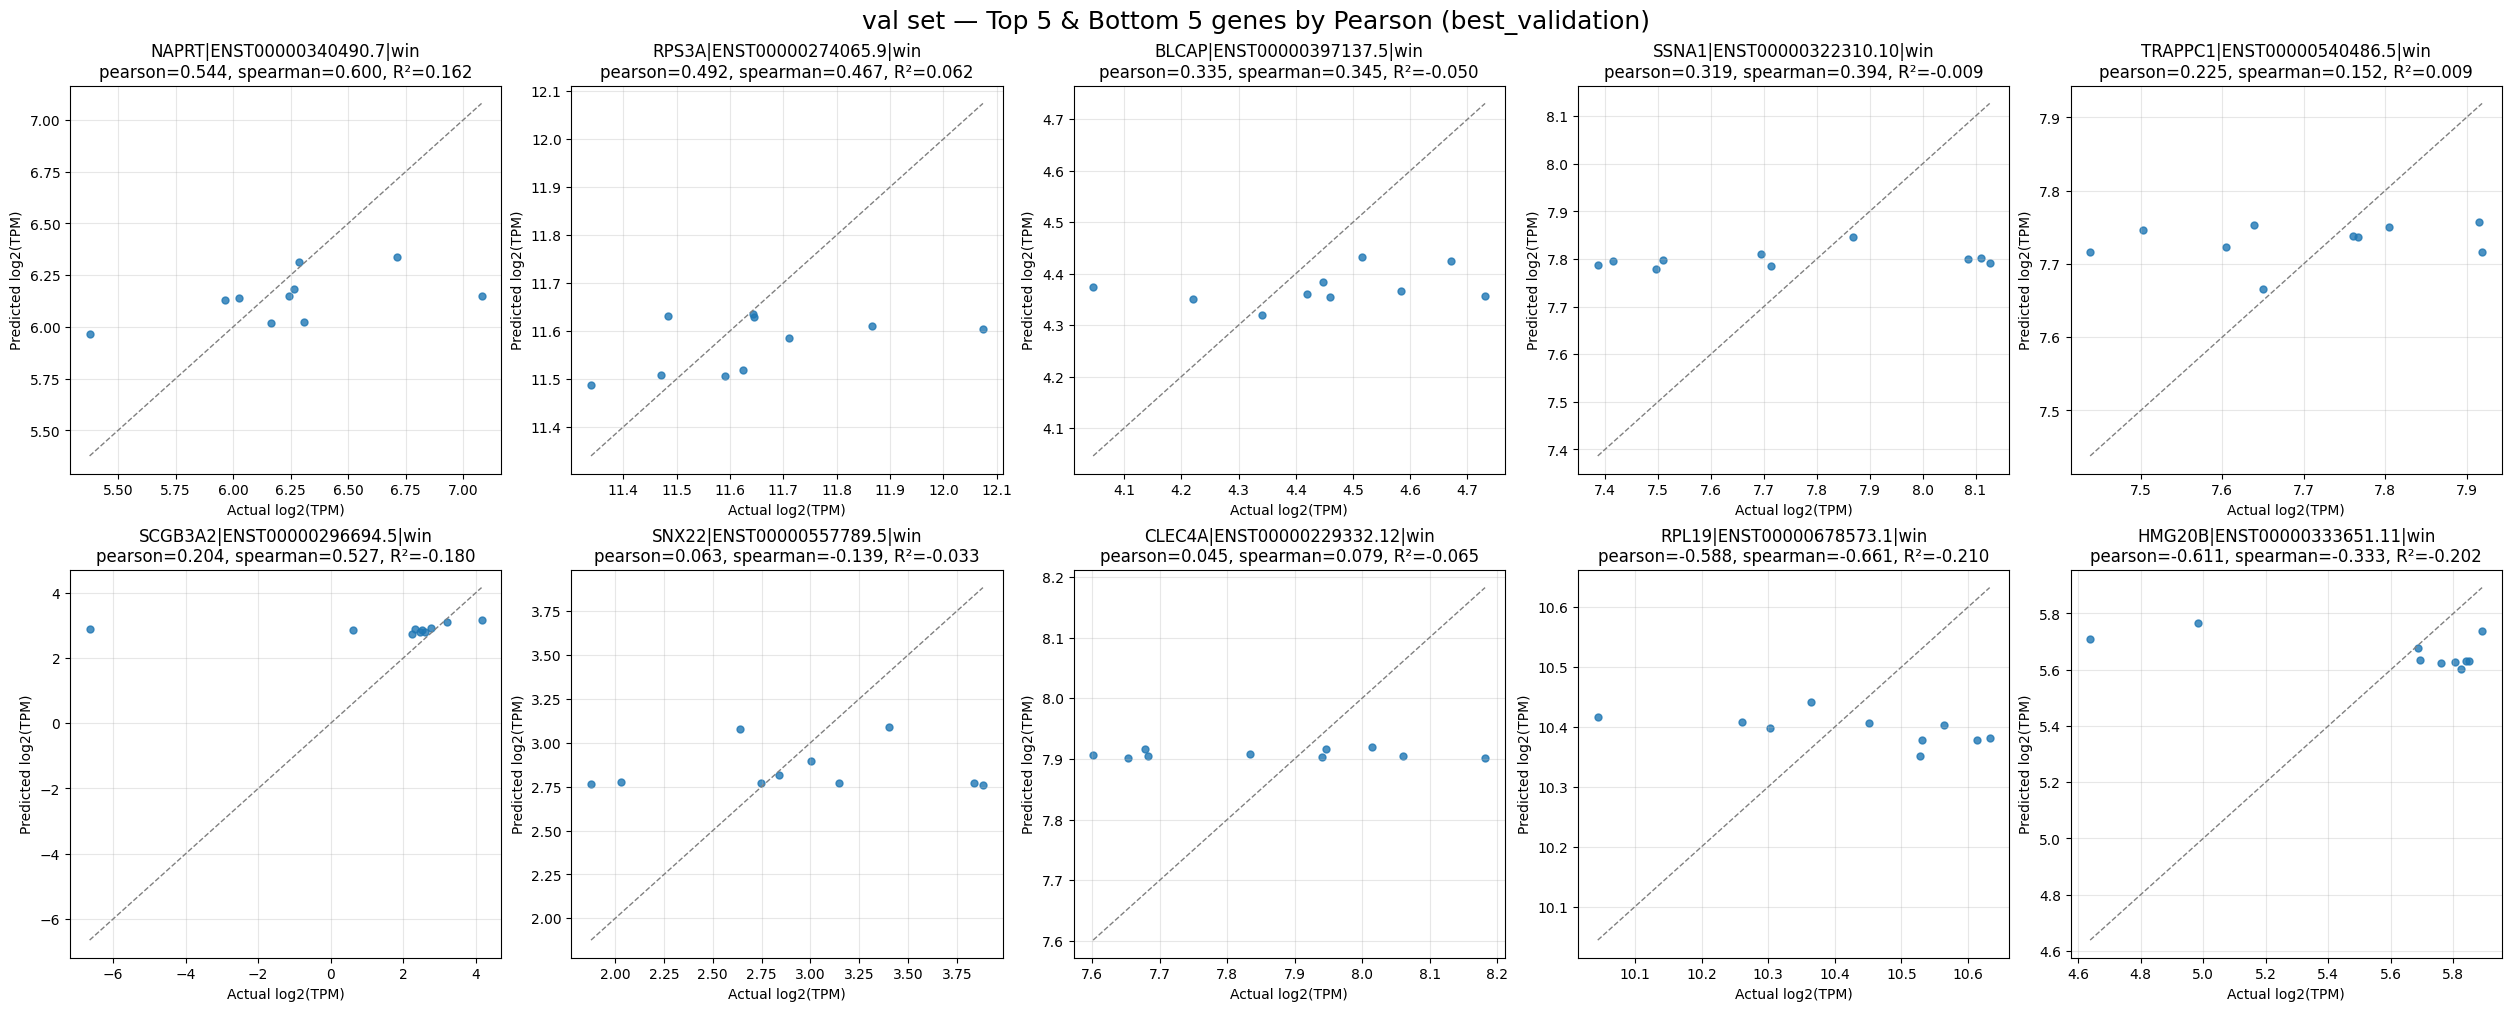

In [ ]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# ============================================================
# 配置：选择数据集 & 模型权重
# ============================================================
SPLIT = "val"                    # "train" | "val" | "test"
MODEL_STATE = "best_validation"  # "best_validation" | "best_training"

# ============================================================
# 按基因计算跨个体 Pearson / Spearman / R²
# ============================================================
preds = result["predictions"].copy()
preds["gene_symbol"] = preds["gene"].map(extract_gene_symbol)

split_preds = preds[(preds["split"] == SPLIT) & (preds["model_state"] == MODEL_STATE)]

gene_metrics = []
for gene_name, group in split_preds.groupby("gene"):
    yt = group["target_diff"].astype(float).values
    yp = group["prediction_diff"].astype(float).values
    if len(yt) < 2 or np.std(yt) == 0 or np.std(yp) == 0:
        continue
    p, _ = pearsonr(yt, yp)
    s, _ = spearmanr(yt, yp)
    r2 = 1 - np.sum((yt - yp) ** 2) / np.sum((yt - np.mean(yt)) ** 2)
    gene_metrics.append({
        "gene": gene_name,
        "gene_symbol": group["gene_symbol"].iloc[0],
        "n": len(yt),
        "pearson": p,
        "spearman": s,
        "r2": r2,
        "targets": yt,
        "predictions": yp,
    })

gene_df = pd.DataFrame(gene_metrics).sort_values("pearson", ascending=False).reset_index(drop=True)

print(f"Split={SPLIT}, Model={MODEL_STATE}, 共 {len(gene_df)} 个基因")
display(gene_df[["gene_symbol", "n", "pearson", "spearman", "r2"]].head(10))

# ============================================================
# 画 Top 5 + Bottom 5 散点图
# ============================================================
n_show = min(10, len(gene_df))
top5 = gene_df.head(n_show // 2)
bottom5 = gene_df.tail(n_show // 2)
selected = pd.concat([top5, bottom5], ignore_index=True)

n_rows = (len(selected) + 4) // 5
fig, axes = plt.subplots(n_rows, min(5, len(selected)),
                         figsize=(25, 5 * n_rows), constrained_layout=True)
if len(selected) == 1:
    axes = [[axes]]

for idx, row in enumerate(selected.itertuples(index=False)):
    ax = axes[idx // 5][idx % 5] if n_rows > 1 or len(selected) > 1 else axes[0]
    yt, yp = row.targets, row.predictions
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())

    ax.scatter(yt, yp, alpha=0.8, s=25)
    ax.plot([lo, hi], [lo, hi], color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{row.gene_symbol}\npearson={row.pearson:.3f}, "
                 f"spearman={row.spearman:.3f}, R²={row.r2:.3f}")
    ax.set_xlabel("Actual log2(TPM)")
    ax.set_ylabel("Predicted log2(TPM)")
    ax.grid(alpha=0.3)

# 隐藏多余子图
for idx in range(len(selected), n_rows * min(5, len(selected))):
    if isinstance(axes, list):
        row, col = idx // min(5, len(selected)), idx % min(5, len(selected))
        if row < len(axes) and col < len(axes[row]):
            axes[row][col].set_visible(False)

fig.suptitle(f"{SPLIT} set — Top {top5.shape[0]} & Bottom {bottom5.shape[0]} genes by Pearson ({MODEL_STATE})",
             fontsize=18)
plt.show()


## 6. 对比实验

修改对应 Cell 中的参数后重新运行即可：

| 参数 | 位置 | 可选值 | 说明 |
|------|------|--------|------|
| `N_GENES` | Cell 3 | `10` / `50` / `97` 等 | 基因数量 |
| `LOSS_TYPE` | Cell 4 | `"huber"` / `"pairwise"` / `"mixed"` | 损失函数 |
| `model_class` | Cell 4 | `SpecificSNPRegressor` / `SpecificSNPTransformerCNN` | 模型架构 |
| `PROJECTION_DIM` | Cell 4 | `32` / `64` / `128` / `256` | 投影维度 |
| `GENE_EMBEDDING_DIM` | Cell 4 | `16` / `32` / `64` | 基因条件向量维度 |
| `DROPOUT` | Cell 4 | `0.0` / `0.1` / `0.2` | Dropout |
| `BATCH_SIZE` | Cell 4 | `8` / `16` / `32` / `64` | 批次大小 |
| `LR` | Cell 4 | `1e-4` / `5e-4` / `1e-3` | 学习率 |
| `WEIGHT_DECAY` | Cell 4 | `0.0` / `1e-4` / `1e-3` | 权重衰减 |

每次实验的 CSV 结果保存在 `OUTPUT_DIR` 下。提示：改 `OUTPUT_DIR` 到不同子目录可以避免覆盖之前的实验。
